In [216]:
# ==================================================
# Configuració del projecte
# ==================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [292]:
# ==================================================
# Imports
# ==================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from src.config import (
    DATA_PROCESSED,
    FIGURES_DIR,
    TABLES_DIR,
)

from src.utils_io import (
    load_csv,
    save_csv,
)

In [220]:
# ==================================================
# Configuració visual
# ==================================================

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

In [222]:
# ==================================================
# Carregar dataset amb indicadors
# ==================================================

print("Carregant dataset amb indicadors...")

df = load_csv(
    DATA_PROCESSED / "indicators_dataset.csv"
)

print("Dataset carregat correctament.")

display(df.head())

Carregant dataset amb indicadors...
Dataset carregat correctament.


,any,tipus_de_territori,territori,renda,preu_lloguer,poblacio_total,Espanya,No consta,Resta de la Unió Europea,Resta del món,...,hut,territori_id,pct_ue,pct_mon,indicador_socio,indicador_housing,indicador_demo,indicador_turisme,indicador_global_pca,indicador_gentrificacio
0,2000,Barri,baro de viver,NaN,NaN,2368,2351.0,0.0,0.0,16.0,...,NaN,0,-1.102333,-1.474730,0.003372,3.692197e-16,-1.288532,1.009294e-17,-1.039312,-0.256695
1,2001,Barri,baro de viver,NaN,NaN,2373,2354.0,0.0,0.0,18.0,...,NaN,0,-1.102333,-1.463835,0.003372,3.692197e-16,-1.283084,1.009294e-17,-1.034918,-0.255605
2,2002,Barri,baro de viver,NaN,NaN,2393,2363.0,0.0,0.0,26.0,...,NaN,0,-1.102333,-1.420709,0.003372,3.692197e-16,-1.261521,1.009294e-17,-1.017526,-0.251293
3,2003,Barri,baro de viver,NaN,NaN,2382,2334.0,0.0,6.0,41.0,...,NaN,0,-1.031472,-1.337246,0.003372,3.692197e-16,-1.184359,1.009294e-17,-0.955288,-0.235860
4,2004,Barri,baro de viver,NaN,NaN,2365,2301.0,0.0,0.0,60.0,...,NaN,0,-1.102333,-1.229980,0.003372,3.692197e-16,-1.166157,1.009294e-17,-0.940606,-0.232220


In [224]:
# ==================================================
# Variables utilitzades pel clustering
# ==================================================

cluster_vars = [

    "indicador_socio",
    "indicador_housing",
    "indicador_demo",
    "indicador_turisme",
    "indicador_gentrificacio",

]

print("\nVariables de clustering:")

print(cluster_vars)


Variables de clustering:
['indicador_socio', 'indicador_housing', 'indicador_demo', 'indicador_turisme', 'indicador_gentrificacio']


In [226]:
# ==================================================
# Preparació de dades
# ==================================================

print("\nPreparant dades...")

df_cluster = (
    df.dropna(subset=cluster_vars)
    .copy()
)


Preparant dades...


In [228]:
# ==================================================
# Escalat
# ==================================================

scaler = StandardScaler()

X = scaler.fit_transform(
    df_cluster[cluster_vars]
)

In [230]:
# ==================================================
# Elbow Method
# ==================================================

print("\nCalculant Elbow Method...")

inertias = []

K = range(1, 11)

for k in K:

    kmeans = KMeans(

        n_clusters=k,
        random_state=42,
        n_init="auto",

    )

    kmeans.fit(X)

    inertias.append(
        kmeans.inertia_
    )


Calculant Elbow Method...


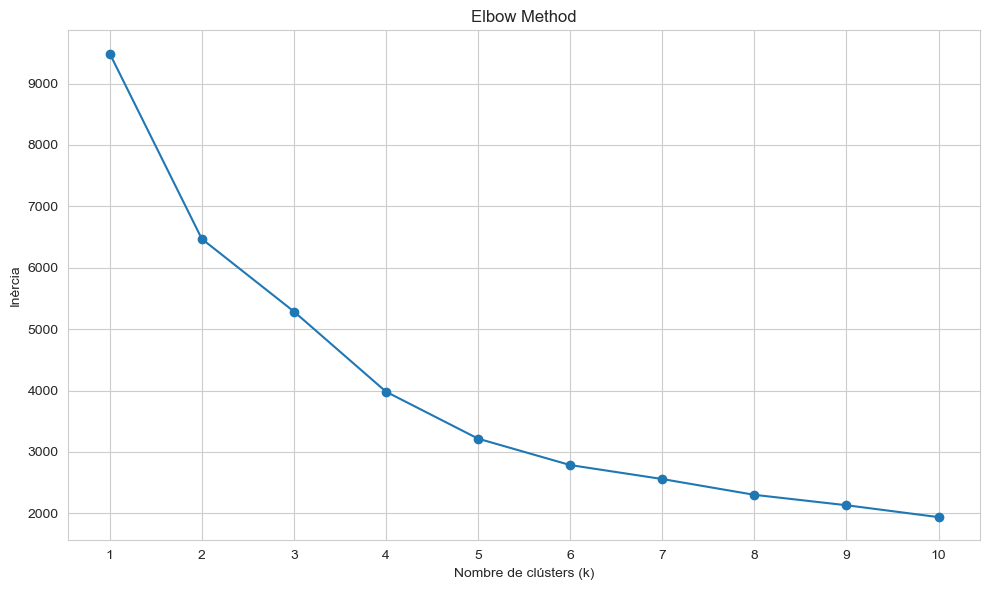

In [232]:
# ==================================================
# Visualització Elbow Method
# ==================================================

plt.figure()

plt.plot(

    K,
    inertias,
    marker="o",

)

plt.xlabel(
    "Nombre de clústers (k)"
)

plt.ylabel(
    "Inèrcia"
)

plt.title(
    "Elbow Method"
)

plt.xticks(K)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "elbow_method.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [234]:
# ==================================================
# Silhouette Score
# ==================================================

print("\nCalculant Silhouette Score...")

silhouette_scores = []

K_sil = range(2, 11)

for k in K_sil:

    kmeans = KMeans(

        n_clusters=k,
        random_state=42,
        n_init="auto",

    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(
        X,
        labels,
    )

    silhouette_scores.append(score)


Calculant Silhouette Score...


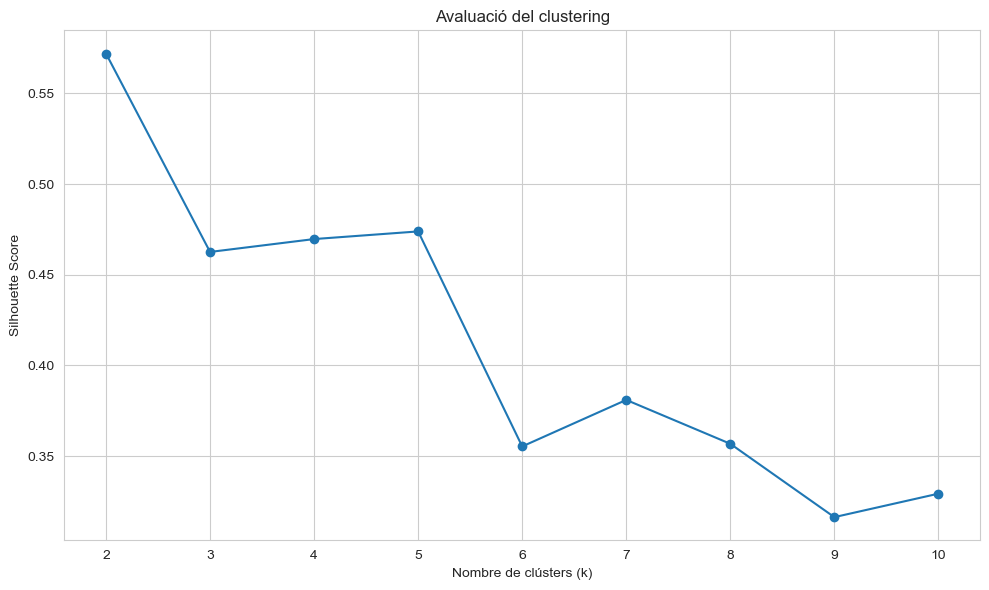

In [236]:
# ==================================================
# Visualització Silhouette Score
# ==================================================

plt.figure()

plt.plot(

    K_sil,
    silhouette_scores,
    marker="o",

)

plt.xlabel(
    "Nombre de clústers (k)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Avaluació del clustering"
)

plt.xticks(K_sil)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "silhouette_method.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [237]:
# ==================================================
# Selecció del nombre final de clústers
# ==================================================

N_CLUSTERS = 4

print(
    f"\nNombre final de clústers seleccionat: {N_CLUSTERS}"
)


Nombre final de clústers seleccionat: 4


In [240]:
# ==================================================
# Clustering final
# ==================================================

print("\nExecutant clustering final...")

kmeans = KMeans(

    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init="auto",

)

df_cluster["cluster"] = (
    kmeans.fit_predict(X)
)


Executant clustering final...


In [242]:
# ==================================================
# Etiquetes interpretatives dels clústers
# ==================================================

cluster_labels = {

    0: "Intermedi",
    1: "Gentrificació residencial",
    2: "Baixa gentrificació",
    3: "Gentrificació turística",

}

df_cluster["cluster_label"] = (
    df_cluster["cluster"]
    .map(cluster_labels)
)

In [244]:
# ==================================================
# PCA per visualització
# ==================================================

print("\nExecutant PCA...")

pca = PCA(
    n_components=2
)

coords = pca.fit_transform(X)

df_cluster["pc1"] = coords[:, 0]

df_cluster["pc2"] = coords[:, 1]


Executant PCA...


In [246]:
# ==================================================
# Variància explicada PCA
# ==================================================

explained_variance = (
    pca.explained_variance_ratio_
)

print("\nVariància explicada:")

print(
    explained_variance
)


Variància explicada:
[0.54089985 0.20499126]


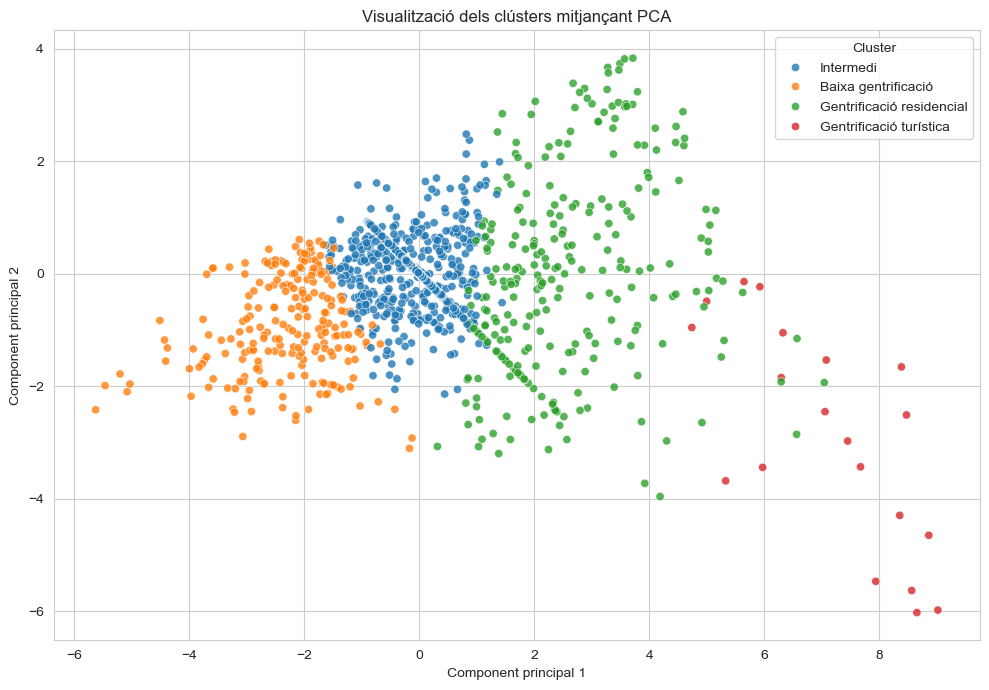

In [248]:
# ==================================================
# Visualització dels clústers
# ==================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(

    data=df_cluster,

    x="pc1",
    y="pc2",

    hue="cluster_label",

    palette="tab10",

    alpha=0.8,

)

plt.title(
    "Visualització dels clústers mitjançant PCA"
)

plt.xlabel(
    "Component principal 1"
)

plt.ylabel(
    "Component principal 2"
)

plt.legend(
    title="Cluster"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "clusters_pca.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [249]:
# ==================================================
# Distribució territorial dels clústers
# ==================================================

cluster_counts = (
    df_cluster["cluster_label"]
    .value_counts()
    .sort_index()
)

print("\nNombre d'observacions per clúster:")

display(cluster_counts)


Nombre d'observacions per clúster:


cluster_label
Baixa gentrificació           229
Gentrificació residencial     288
Gentrificació turística        20
Intermedi                    1361
Name: count, dtype: int64

In [252]:
# ==================================================
# Perfil mitjà dels clústers
# ==================================================

cluster_profile = (

    df_cluster
    .groupby("cluster_label")[cluster_vars]
    .mean()
    .round(2)

)

print("\nPerfil mitjà dels clústers:")

display(cluster_profile)


Perfil mitjà dels clústers:


,indicador_socio,indicador_housing,indicador_demo,indicador_turisme,indicador_gentrificacio
cluster_label,,,,,
Baixa gentrificació,-0.60,-1.14,-0.06,-0.21,-0.58
Gentrificació residencial,0.47,0.87,1.20,0.10,0.66
Gentrificació turística,0.46,1.34,1.13,5.00,1.77
Intermedi,0.00,-0.01,-0.26,-0.06,-0.07


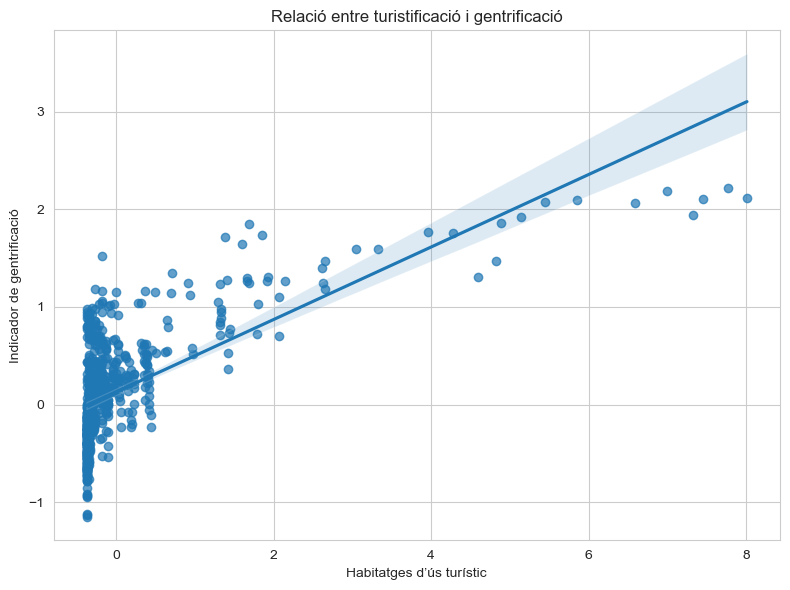

In [308]:
# ==================================================
# HUTs vs identificador_gentrificació
# ==================================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='hut',
    y='indicador_gentrificacio',
    scatter_kws={'alpha':0.7}
)

plt.xlabel('Habitatges d’ús turístic')
plt.ylabel('Indicador de gentrificació')

plt.title('Relació entre turistificació i gentrificació')

plt.savefig(
    FIGURES_DIR / "hut_vs_ig.png",
    dpi=300,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()

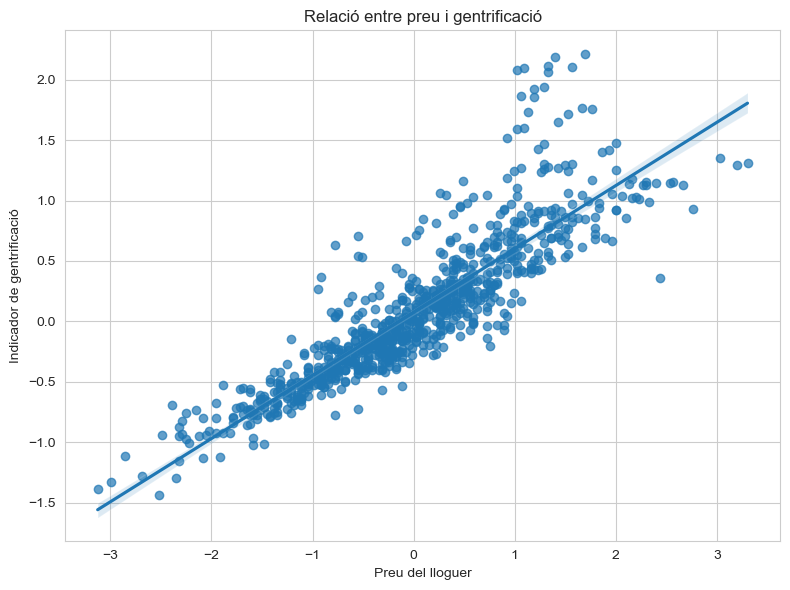

In [312]:
# ==================================================
# preu vs identificador_gentrificació
# ==================================================

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='preu_lloguer',
    y='indicador_gentrificacio',
    scatter_kws={'alpha':0.7}
)

plt.xlabel('Preu del lloguer')
plt.ylabel('Indicador de gentrificació')

plt.title('Relació entre preu i gentrificació')

plt.savefig(
    FIGURES_DIR / "preu_vs_ig.png",
    dpi=300,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()

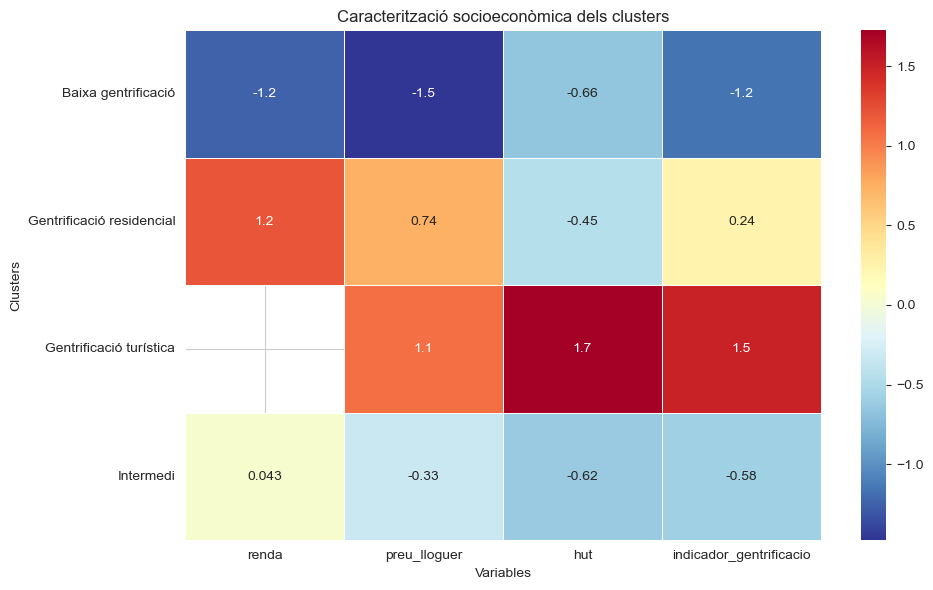

In [270]:
# ==================================================
# Exportació perfil clústers
# ==================================================

variables = [
    'renda',
    'preu_lloguer',
    'hut',
    'indicador_gentrificacio'
]

cluster_profile = df_cluster.groupby('cluster_label')[variables].mean()

scaler = StandardScaler()
cluster_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_scaled,
    annot=True,
    cmap='RdYlBu_r',
    linewidths=0.5
)

plt.title('Caracterització socioeconòmica dels clusters')
plt.xlabel('Variables')
plt.ylabel('Clusters')

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'heatmap_clusters.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [204]:
# ==================================================
# Exportació perfil clústers
# ==================================================

latex_table = cluster_profile.to_latex(

    caption=(
        "Perfil mitjà dels clústers "
        "segons els indicadors construïts."
    ),

    label="tab:cluster_profile",

    column_format="lccccc",

)

with open(
    TABLES_DIR / "cluster_profile.tex",
    "w",
    encoding="utf-8",
) as f:

    f.write(latex_table)

print(
    "\nTaula LaTeX exportada."
)


Taula LaTeX exportada.


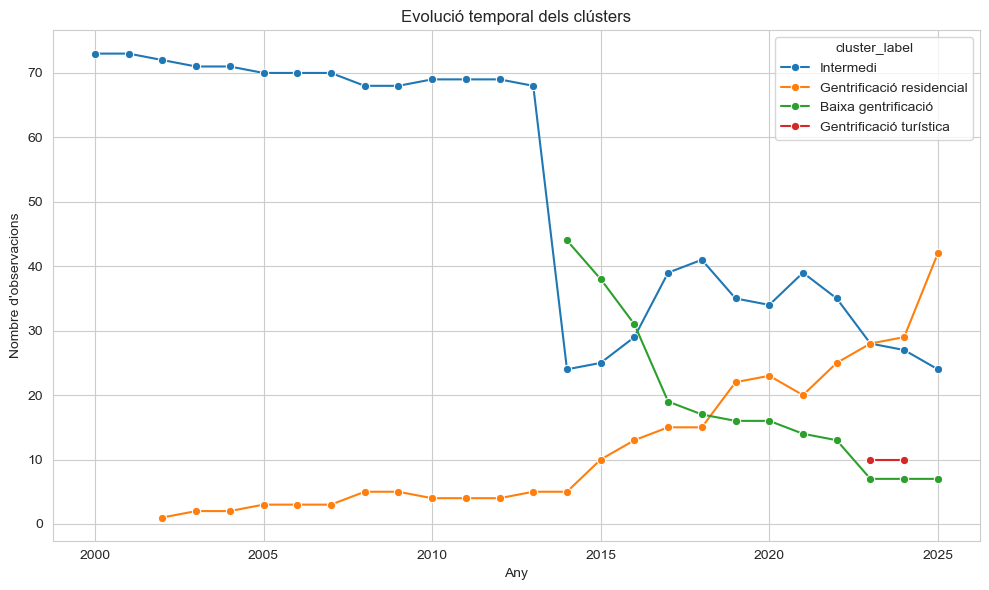

In [206]:
# ==================================================
# Evolució temporal dels clústers
# ==================================================

cluster_time = (

    df_cluster
    .groupby(["any", "cluster_label"])
    .size()
    .reset_index(name="n")

)

plt.figure(figsize=(10, 6))

sns.lineplot(

    data=cluster_time,

    x="any",
    y="n",

    hue="cluster_label",
    marker="o",

)

plt.title(
    "Evolució temporal dels clústers"
)

plt.xlabel("Any")

plt.ylabel(
    "Nombre d'observacions"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucio_clusters.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [208]:
# ==================================================
# Exportació dataset final
# ==================================================

save_csv(

    df_cluster,

    DATA_PROCESSED / "cluster_dataset.csv"

)

print(
    "\nDataset de clústers exportat correctament."
)


Dataset de clústers exportat correctament.


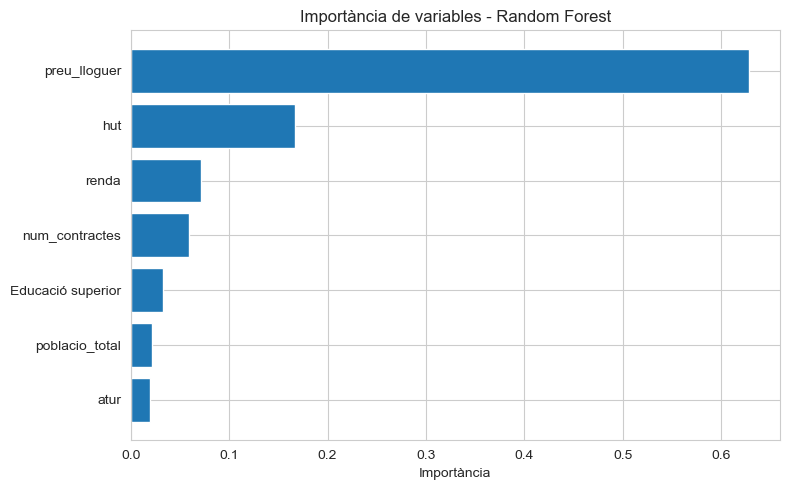

In [302]:
features = [
    'renda',
    'preu_lloguer',
    'hut',
    'Educació superior',
    'poblacio_total',
    'atur',
    'num_contractes'
]

df_model = df.dropna(subset=features + ['indicador_gentrificacio'])

X = df_model[features]
y = df_model['indicador_gentrificacio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Variable': features,
    'Importancia': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importancia',
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Variable'],
    importance_df['Importancia']
)

plt.xlabel('Importància')
plt.title('Importància de variables - Random Forest')

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "importancia_rf.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [304]:
importance_df = pd.DataFrame({
    'Variable': features,
    'Importancia': rf.feature_importances_
})

importance_df.sort_values(
    'Importancia',
    ascending=False
)

,Variable,Importancia
1,preu_lloguer,0.628602
2,hut,0.166539
0,renda,0.071522
6,num_contractes,0.059285
3,Educació superior,0.032950
4,poblacio_total,0.021400
5,atur,0.019702
